<a href="https://colab.research.google.com/github/fernandolievano/aprendizaje-automatico-1/blob/main/%5BAA1%5D_TP3_Regularizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo Práctico 3 - Aprendizaje Automático 1
## Regularización


### Objetivos
- Aprender como funcionan los diferentes mecanismos de regularización.
- Reproducir código fuente de tutoriales.
- Documentar procesos de ciencia de datos.

## Setup Inicial

### Librerías

In [13]:
# Tratamiento de datos
import pandas as pd
import numpy as np

# Gráficos
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 8
import seaborn as sns

# Preprocesado y modelado
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNetCV

# Configuración warnings
import warnings
warnings.filterwarnings('ignore')


### Utils

In [14]:
# Funciones reutilizables
def print_title(title: str):
    print('===' * 30)
    print(f' 🔷 {title}')
    print('===' * 30 + '\n')

# Regularización Rige, Lasso y Elastic Net

## Planteamiento del Problema

 El departamento de calidad de una empresa de alimentación se encarga de medir el contenido en grasa de la carne que comercializa. Este estudio se realiza mediante técnicas de análitica química, un proceso relativamente costos en tiempo y recursos.
 Una alternativa que permitiría reducir costes y optimizar tiempo es emplear un **espectrofotómetro** (instrumento que detecta la absorbancia de un materiall a diferentes tipos de luz basado en sus características) e inferir el contenido en grasa a partir de sus medidas.

Antes de dar por válida esta nueva técnica, la empresa necesita comprobar qué margen de error tiene respecto al análisis químico. Para ello, se mide el espectro de absorbancia a 100 longitudes de onda en 215 muestras de carne, cuyo contenido en grasa se obtiene también por análisis químico, y se entrena un modelo con el objetivo de predecir el contenido en grasa a partri de los vaores dados por el espectrofotómetro.

Los datos [**meatspec.csv**](https://people.bath.ac.uk/jjf23/LMR/python/lmrcsv.zip) empleados en este ejemplo se han obtenido del libro *Linear Models with R, Second Edition*.

## Datos

El set de datos contienen 101 columnas. Las 100 primeras nombradas como $V_1$, ... $V_100$ recogen el valor de absorbancia para cada una de las 100 longitudes de onda analizadas (predictores), y la columna *fat* el contenido en grasa medido por técnicas químicas (variable respuesta)

In [15]:
# Obtenemos el dataset desde la URL pública, en formato .zip
!wget https://people.bath.ac.uk/jjf23/LMR/python/lmrcsv.zip
# Descomprimimos el .zip
!unzip lmrcsv.zip
# Localizamos el .csv, que está dentro de la carpeta data
df = pd.read_csv('data/meatspec.csv')
df = df.drop(columns=df.columns[0])

--2026-05-23 03:08:18--  https://people.bath.ac.uk/jjf23/LMR/python/lmrcsv.zip
Resolving people.bath.ac.uk (people.bath.ac.uk)... 138.38.44.91
Connecting to people.bath.ac.uk (people.bath.ac.uk)|138.38.44.91|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 161544 (158K) [application/zip]
Saving to: ‘lmrcsv.zip.1’

lmrcsv.zip.1        100%[===================>] 157.76K   553KB/s    in 0.3s    

2026-05-23 03:08:18 (553 KB/s) - ‘lmrcsv.zip.1’ saved [161544/161544]

Archive:  lmrcsv.zip
replace data/abrasion.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: data/abrasion.csv       
  inflating: data/airpass.csv        
  inflating: data/cars.csv           
  inflating: data/chmiss.csv         
  inflating: data/chredlin.csv       
  inflating: data/coagulation.csv    
  inflating: data/composite.csv      
  inflating: data/corrosion.csv      
  inflating: data/eco.csv            
  inflating: data/families.csv       
  inflating: data/fat.csv            
 

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 215 entries, 0 to 214
Columns: 101 entries, V1 to fat
dtypes: float64(101)
memory usage: 169.8 KB


In [17]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V92,V93,V94,V95,V96,V97,V98,V99,V100,fat
0,2.61776,2.61814,2.61859,2.61912,2.61981,2.62071,2.62186,2.62334,2.62511,2.62722,...,2.98145,2.96072,2.94013,2.91978,2.89966,2.87964,2.85960,2.83940,2.81920,22.5
1,2.83454,2.83871,2.84283,2.84705,2.85138,2.85587,2.86060,2.86566,2.87093,2.87661,...,3.29186,3.27921,3.26655,3.25369,3.24045,3.22659,3.21181,3.19600,3.17942,40.1
2,2.58284,2.58458,2.58629,2.58808,2.58996,2.59192,2.59401,2.59627,2.59873,2.60131,...,2.68951,2.67009,2.65112,2.63262,2.61461,2.59718,2.58034,2.56404,2.54816,8.4
3,2.82286,2.82460,2.82630,2.82814,2.83001,2.83192,2.83392,2.83606,2.83842,2.84097,...,2.97367,2.94951,2.92576,2.90251,2.87988,2.85794,2.83672,2.81617,2.79622,5.9
4,2.78813,2.78989,2.79167,2.79350,2.79538,2.79746,2.79984,2.80254,2.80553,2.80890,...,3.30025,3.27907,3.25831,3.23784,3.21765,3.19766,3.17770,3.15770,3.13753,25.5


## Relación entre variables

Para poder establecer un modelo lineal múltiple primero se estudia la relación que existe entre variables. Esta información es crítica para poder indentificar los mejores predictores del modelo y poder detectar colinealidad entre predictores. Como complemento, es recomendable representar la distribución de cada variable mediante histogramas.

In [18]:
# Correlación entre columnas numéricas

def tidy_corr_matrix(corr_mat):
    """
    Función para convertir uuna matriz de correlación de pandas en formato tidy
    """
    corr_mat = corr_mat.stack().reset_index()
    corr_mat.columns = ['variable_1', 'variable_2', 'r']
    corr_mat = corr_mat.loc[corr_mat['variable_1'] != corr_mat['variable_2'], :]
    corr_mat['abs_r'] = np.abs(corr_mat['r'])
    corr_mat = corr_mat.sort_values('abs_r', ascending=False)

    return(corr_mat)

corr_matrix = df.select_dtypes(include=['float64', 'int']).corr(method='pearson')

display(tidy_corr_matrix(corr_matrix).head(5))

,variable_1,variable_2,r,abs_r
1019,V11,V10,0.999996,0.999996
919,V10,V11,0.999996,0.999996
1121,V12,V11,0.999996,0.999996
1021,V11,V12,0.999996,0.999996
917,V10,V9,0.999996,0.999996


 🔷 Visualización de la matriz de correlaciones



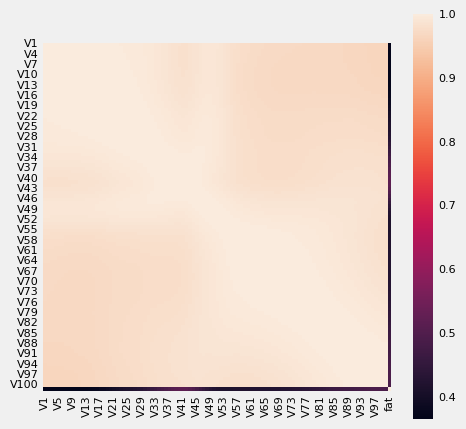

In [19]:
print_title('Visualización de la matriz de correlaciones')

# Heatmap matriz de correlaciones
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
sns.heatmap(
    data = corr_matrix,
    square = True,
    ax = ax
)
ax.tick_params(labelsize=8)

> ℹ️ Muchas de las variables están altamente correlacionadas (correlación absoluta > 0.8), lo que supone un problema a la hora de emplear modelos de regresión lineal.

## Partición de Datos

Se procede a ajustar varios modelos lineales con y sin regularización, con el objetivo de identificar cuál de ellos es capaz de predecir mejor el contenido en grasa de la carne en función de las señales registradas por el espectrofotómetro.

Para poder evaluar la capacidad predictiva de cada modelo, se dividen las observaciones disponibles en dos grupos: uno de entrenamiento (70%) y otro de test (30%)

In [20]:
# División de los datos en train y test

X = df.drop(columns='fat')
y = df['fat']

X_train, X_test, y_train, y_test = train_test_split(
                                        X,
                                        y,
                                        train_size=0.7,
                                        random_state=1234,
                                        shuffle=True
                                    )

## Escalado

Los modelos de regresión lineal con regularización *Ridge*, *Lasso*, y **Elastic Net** penalizan la magnitud de los coeficientes del modelo, lo que hace necesario que todos los predictores estén en la misma escala. Para ello se puede emplear estandarización o normalización, en este caso, se realizará estandarización.

In [21]:
# Escalado

scaler = StandardScaler().set_output(transform='pandas')
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Mínimos cuadrados (OLS)

In [22]:
model = LinearRegression()
model.fit(X=X_train, y=y_train)

LinearRegression()

 🔷 Coeficientes del modelo



Text(0.5, 1.0, 'Coeficientes del modelo')

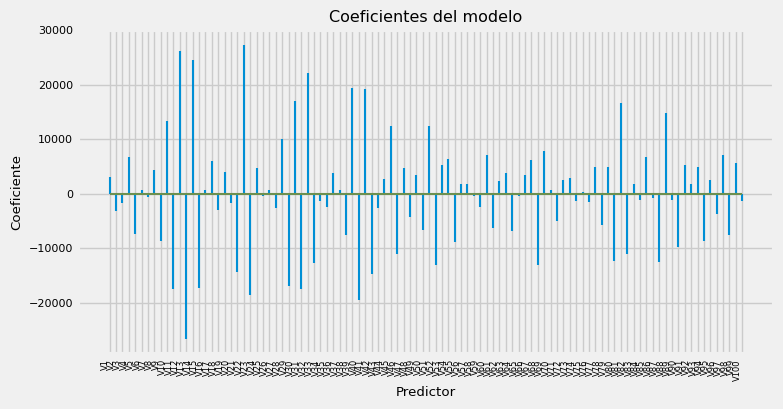

In [23]:
print_title('Coeficientes del modelo')

# Dataframe de coeficientes
df_coef = pd.DataFrame({
                        'predictor': X_train.columns,
                        'coef': model.coef_.flatten()
                    })

# Gráfico
fig, ax = plt.subplots(figsize=(8,4))
ax.stem(df_coef.predictor, df_coef.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('Predictor')
ax.set_ylabel('Coeficiente')
ax.set_title('Coeficientes del modelo')

In [26]:
print_title('Predicciones Test')

predictions = model.predict(X=X_test)
predictions = predictions.flatten()
predictions[:10]

 🔷 Predicciones Test



array([36.88226752, 62.47992661, 61.04825535,  9.95161352, 18.11993067,
        6.56158193, 28.42860453,  9.18085599, 15.56800749, 16.50461443])

In [27]:
print_title('Error de test de modelo')

rmse_ols = root_mean_squared_error(y_true=y_test, y_pred=predictions)
print(f'El error (RMSE) de test: {rmse_ols}')

 🔷 Error de test de modelo

El error (RMSE) de test: 3.8396675856299343


## Ridge

Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)

In [28]:
model = RidgeCV(
            alphas=np.logspace(-20, 2, 200),
            scoring='neg_root_mean_squared_error',
            fit_intercept=True,
            store_cv_results=True
        )
_ = model.fit(X=X_train, y=y_train)

> Cuando se utiliza regularización, es útil evaluar cómo se aproximan a cero los coeficientes a medida que se incrementa el valor de alpha así como la evolución del error de validación cruzada en función del alpha empleado.

 🔷 Evolución de los coefiicientes en función de alpha



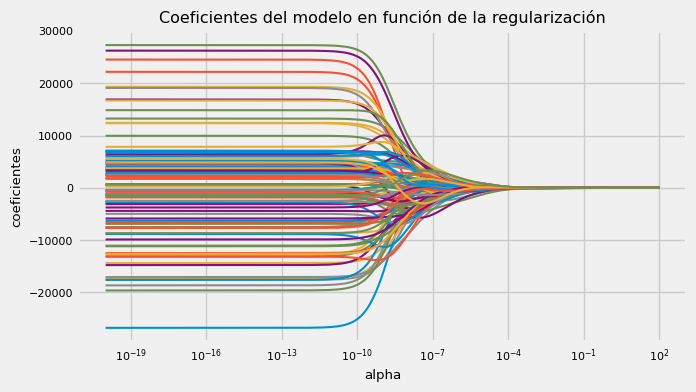

In [31]:
print_title('Evolución de los coefiicientes en función de alpha')

alphas = model.alphas
coefs = []

for alpha in alphas:
    temp_model = Ridge(alpha=alpha, fit_intercept=True)
    temp_model.fit(X=X_train, y=y_train)
    coefs.append(temp_model.coef_.flatten())

# Gráfico
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');
plt.axis('tight')
plt.show()

> Se puede ver como a medida que el valor de alpha aumenta, la regularización es mayor y el valor de los coeficientes se reduce.

 🔷 Evolución del error en función de alpha



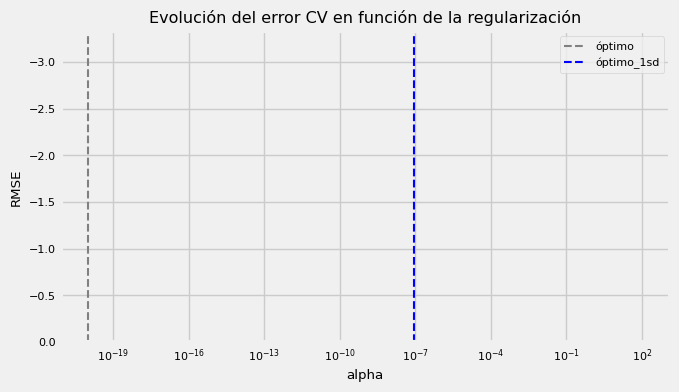

In [32]:
print_title('Evolución del error en función de alpha')

# modelo.cv_results_ almacena el resultado de cv para cada valor de alpha
# tiene dimensiones (n_samples, n_alphas) o (n_samples, n_targets, n_alphas)
cv_results = model.cv_results_

# multiplicamos por -1 para obtener el RMSE positivo
rmse_cv = -1 * cv_results.mean(axis=0)
rmse_sd = cv_results.std(axis=0)

# identificames el óptimo y el òptimo + 1std
min_rmse = np.min(rmse_cv)
sd_min_rmse = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimal = model.alphas[np.argmin(rmse_cv)].item()
optimal_1sd = model.alphas[rmse_cv == min_rmse_1sd].item()

# Gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(model.alphas, rmse_cv)
ax.fill_between(
    model.alphas,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x         = optimal,
    c         = "gray",
    linestyle = '--',
    label     = 'óptimo'
)
ax.axvline(
    x         = optimal_1sd,
    c         = "blue",
    linestyle = '--',
    label     = 'óptimo_1sd'
)
ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend();

In [33]:
print_title('Mejor valor alpha encontrado')

print(f'Modelo valor de alpha encontrado: {model.alpha_}')

 🔷 Mejor valor alpha encontrado

Modelo valor de alpha encontrado: 5.0526310653357e-06


 🔷 Coeficientes del modelo



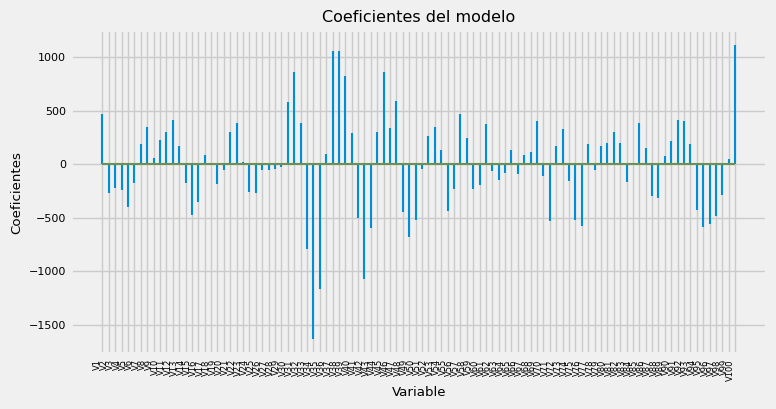

In [34]:
print_title('Coeficientes del modelo')

df_coef = pd.DataFrame({
                        'predictor': X_train.columns,
                        'coef': model.coef_.flatten()
                    })

fig, ax = plt.subplots(figsize=(8,4))
ax.stem(df_coef.predictor, df_coef.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('Variable')
ax.set_ylabel('Coeficientes')
ax.set_title('Coeficientes del modelo');

> En comparación al modelo por mínimos cuadrados ordinarios, con ridge, el orden de magnitud de los coeficientes es mucho menor.

In [35]:
print_title('Predicciones test')

predictions = model.predict(X=X_test)
predictions = predictions.flatten()
predictions[:10]

 🔷 Predicciones test



array([43.18344348, 40.77188673, 51.13840201,  9.98568524, 17.87646593,
        7.6652655 , 28.10025725,  8.19516261, 14.7508043 , 14.43546212])

In [36]:
print_title('Error de test de modelo')

rmse_ridge = root_mean_squared_error(y_true=y_test, y_pred=predictions)
print(f'El error (RMSE) de test: {rmse_ridge}')

 🔷 Error de test de modelo

El error (RMSE) de test: 2.3915887532773366


> Las predicciones del modelo final se alejan en promedio 2.45 unidades del valor real.

## Lasso

In [37]:
print_title('Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)')

# por defecto, lassocv utiliza el mean squared error
model = LassoCV(
            alphas=np.logspace(-5, 3, 200),
            cv=5
        )

_ = model.fit(X=X_train, y=y_train)

 🔷 Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)



> Cuando se utiliza regularización, es útil evaluar cómo se aproximan a cero los coeficientes a medida que se incrementa el valor de alpha así como la evolución del error de validación cruzada en función del alpha empleado.

 🔷 Evolución de los coeficientes en función de alpha



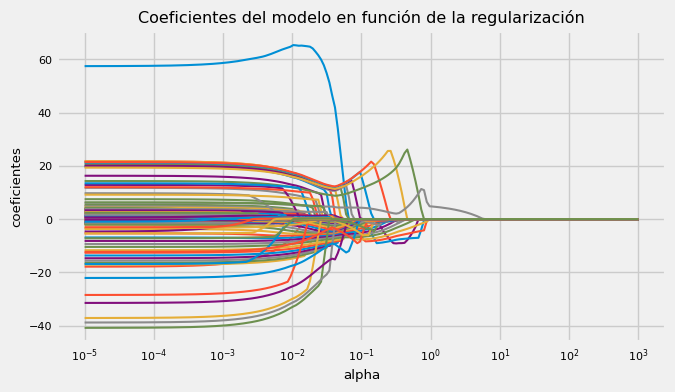

In [38]:
print_title('Evolución de los coeficientes en función de alpha')

alphas = model.alphas_
coefs = []

for alpha in alphas:
    temp_model = Lasso(alpha=alpha, fit_intercept=True)
    temp_model.fit(X=X_train, y=y_train)
    coefs.append(temp_model.coef_.flatten())

# Gráfico
fig, ax = plt.subplots(figsize=(7, 3.84))
ax.plot(alphas, coefs)
ax.set_xscale('log')
ax.set_xlabel('alpha')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo en función de la regularización');

> Se observa como a medida que el valor de alpha crece, la regularización es mayor y más predictores quedan excluídos (los que tienen coeficiente 0)

 🔷 Número de predictores incluídos (coeficiente != 0) en función de alpha



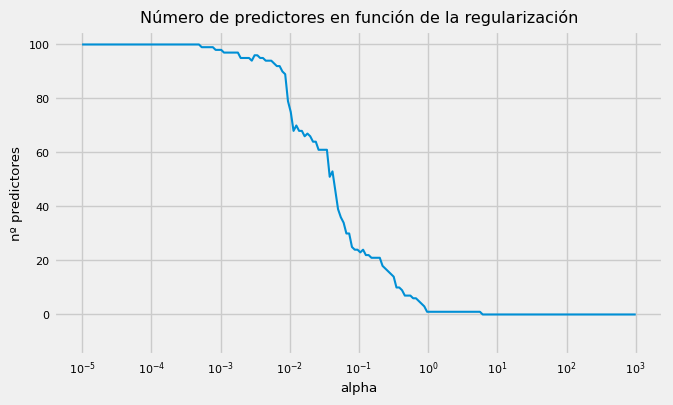

In [39]:
print_title('Número de predictores incluídos (coeficiente != 0) en función de alpha')

alphas = model.alphas_
n_predictores = []

for alpha in alphas:
    temp_model = Lasso(alpha=alpha, fit_intercept=True)
    temp_model.fit(X=X_train, y=y_train)
    non_zero_coef = np.sum(temp_model.coef_.flatten() != 0)
    n_predictores.append(non_zero_coef)

# Gráfico
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, n_predictores)
ax.set_xscale('log')
ax.set_ylim([-15, None])
ax.set_xlabel('alpha')
ax.set_ylabel('nº predictores')
ax.set_title('Número de predictores en función de la regularización');

 🔷 Evolución del error en función de alpha



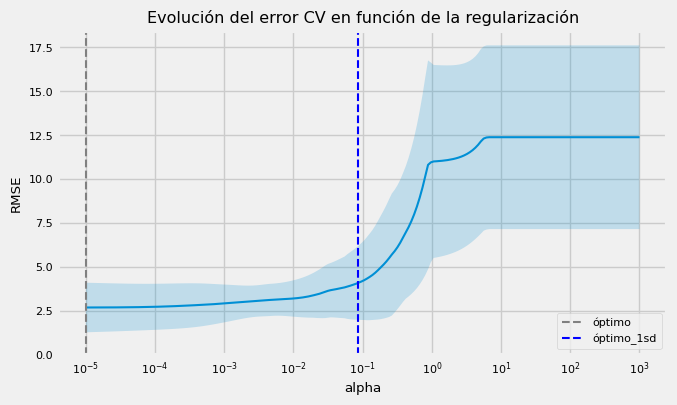

In [41]:
print_title('Evolución del error en función de alpha')

# modelo.mse_path almacena el mse de cv para cada valor de alpha
# tiene dimensiones (n_alphas, n_folds)
mse_cv = model.mse_path_.mean(axis=1)
mse_sd = model.mse_path_.std(axis=1)

# aplicamos raíz cuadrada para pasar de mse a rmse
rmse_cv = np.sqrt(mse_cv)
rmse_sd = np.sqrt(mse_sd)

# identificamos el óptimo y el óptimo + 1std
min_rmse = np.min(rmse_cv)
sd_min_rmse = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimal = model.alphas_[np.argmin(rmse_cv)].item()
optimal_1sd = model.alphas_[rmse_cv == min_rmse_1sd]

# gráfico del error +- 1 desviación estándar
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(model.alphas_, rmse_cv)
ax.fill_between(
    model.alphas_,
    rmse_cv + rmse_sd,
    rmse_cv - rmse_sd,
    alpha=0.2
)
ax.axvline(
    x = optimal,
    c = "gray",
    linestyle = '--',
    label = 'óptimo'
)
ax.axvline(
    x = optimal_1sd,
    c = "blue",
    linestyle = '--',
    label = 'óptimo_1sd'
)
ax.set_xscale('log')
ax.set_ylim([0,None])
ax.set_title('Evolución del error CV en función de la regularización')
ax.set_xlabel('alpha')
ax.set_ylabel('RMSE')
plt.legend()

In [42]:
print_title('Mejor valor alpha encontrado')

print(f'Modelo valor de alpha encontrado: {model.alpha_}')

 🔷 Mejor valor alpha encontrado

Modelo valor de alpha encontrado: 1e-05


In [44]:
print_title('Mejor valor alpha encontrado + 1sd')

min_rmse = np.min(rmse_cv)
sd_min_rmse = rmse_sd[np.argmin(rmse_cv)]
min_rmse_1sd = np.max(rmse_cv[rmse_cv <= min_rmse + sd_min_rmse])
optimal = model.alphas_[np.argmin(rmse_cv)]
optimal_1sd = model.alphas_[rmse_cv == min_rmse_1sd].item()

print(f'Mejor valor de alpha encontrado + 1 desviación estándar: {optimal_1sd}')

 🔷 Mejor valor alpha encontrado + 1sd

Mejor valor de alpha encontrado + 1 desviación estándar: 0.08703591361485166


> Se entrena de nuevo al modelo, esta vez empleando el mayor valor de alpha cuyo error está a menos de una desviación típica del mínimo encontrado en la validación cruzada.

In [46]:
print_title('Mejor modelo alpha óptimo + 1sd')

model = Lasso(alpha=optimal_1sd)
model.fit(X=X_train, y=y_train)

 🔷 Mejor modelo alpha óptimo + 1sd



Lasso(alpha=0.08703591361485166)

In [47]:
print_title('Coeficientes del modelo')

df_coef = pd.DataFrame({
                        'predictor': X_train.columns,
                        'coef': model.coef_.flatten()
                    })

# predictores incluídos en el modelo (coef != 0)
df_coef[df_coef.coef != 0].reset_index(drop=True)

 🔷 Coeficientes del modelo



,predictor,coef
0,V8,-2.809618
1,V9,-7.678029
2,V10,-6.773139
3,V11,-6.028624
4,V12,-5.284843
5,V13,-4.547397
6,V14,-3.780134
7,V15,-3.064607
8,V16,-2.425411
9,V17,-1.873268


> De los 100 predictores disponibles, el modelo final solo incluye 24.

 🔷 Coeficientes del modelo



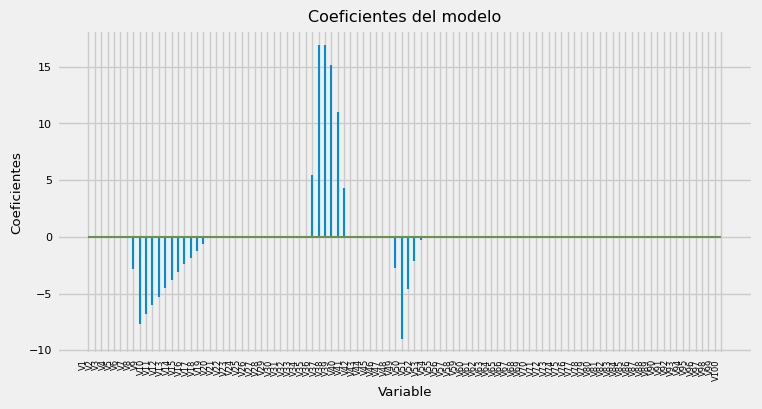

In [48]:
print_title('Coeficientes del modelo')

fig, ax = plt.subplots(figsize=(8,4))
ax.stem(df_coef.predictor, df_coef.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('Variable')
ax.set_ylabel('Coeficientes')
ax.set_title('Coeficientes del modelo');

In [49]:
print_title('Predicciones test')

predictions = model.predict(X=X_test)
predictions = predictions.flatten()
predictions[:10]

 🔷 Predicciones test



array([34.35041421, 53.75222685, 36.17366435, 11.74672533, 15.1183471 ,
        6.35327526, 24.5488085 ,  7.48191556, 13.46044097, 18.71293633])

In [50]:
print_title('Error de test del modelo')

rmse_lasso = root_mean_squared_error(y_true=y_test, y_pred=predictions)
print(f'El error (RMSE) de test: {rmse_lasso}')

 🔷 Error de test del modelo

El error (RMSE) de test: 3.747834638323956


> Las predicciones del modelo final se alejan en promedio 3.95 unidades de valor real, utilizando solo 24 de los 100 predictores disponibles.

## Elastic net

In [51]:
print_title('Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)')

model = ElasticNetCV(
            l1_ratio = [0, 0.1, 0.5, 0.7, 0.9, 0.95, 0.99],
            alphas   = np.logspace(-10, 3, 200),
            cv       = 5
         )
_ = model.fit(X = X_train, y = y_train)

 🔷 Creación y entrenamiento del modelo (con búsqueda por CV del valor óptimo alpha)



In [52]:
print_title('Evolución del error en función de alpha y l1_ratio')

# tiene dimensiones (n_l1_ratio, n_alpha, n_folds)
# error medio de las 10 particiones por cada valor de alpha y l1_ratio
mean_error_cv = model.mse_path_.mean(axis=2)

# el resultado es un array de dimensiones (n_l1_ratio, n_alpha)
# se convierte en un dataframe
df_results_cv = pd.DataFrame(
                        data   = mean_error_cv.flatten(),
                        index  = pd.MultiIndex.from_product(
                                    iterables = [model.l1_ratio, model.alphas_],
                                    names     = ['l1_ratio', 'modelo.alphas_']
                                 ),
                        columns = ["mse_cv"]
                    )
df_results_cv['rmse_cv'] = np.sqrt(df_results_cv['mse_cv'])
df_results_cv = df_results_cv.reset_index().sort_values('mse_cv', ascending=True)
df_results_cv

 🔷 Evolución del error en función de alpha y l1_ratio



,l1_ratio,modelo.alphas_,mse_cv,rmse_cv
1351,0.99,1.366716e-07,7.313915,2.704425
1352,0.99,1.175850e-07,7.313916,2.704425
1350,0.99,1.588565e-07,7.313945,2.704431
1353,0.99,1.011638e-07,7.313964,2.704434
1349,0.99,1.846425e-07,7.313992,2.704439
...,...,...,...,...
628,0.70,1.482021e+01,153.374640,12.384452
627,0.70,1.722586e+01,153.374640,12.384452
629,0.70,1.275051e+01,153.374640,12.384452
630,0.70,1.096986e+01,153.374640,12.384452


 🔷 Mejor valor encontrado para cada l1_ratio



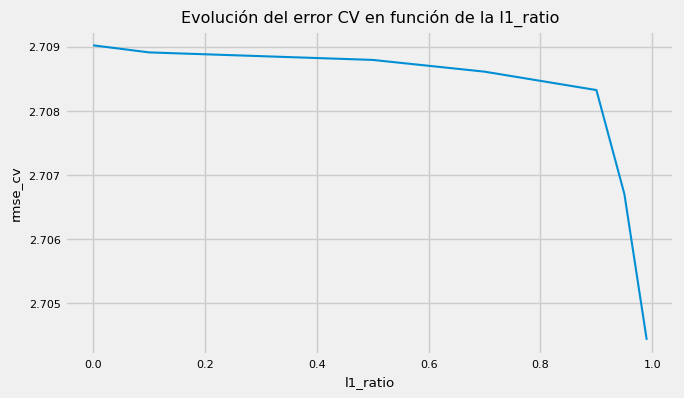

In [54]:
print_title('Mejor valor encontrado para cada l1_ratio')

fig, ax = plt.subplots(figsize=(7, 4))
df_results_cv.groupby('l1_ratio')['rmse_cv'].min().plot(ax = ax)
ax.set_title('Evolución del error CV en función de la l1_ratio')
ax.set_xlabel('l1_ratio')
ax.set_ylabel('rmse_cv');

In [55]:
print_title('Mejor valor alpha y l1_ratio encontrado')

print(f"Mejor valor de alpha encontrado: {model.alpha_}")
print(f"Mejor valor de l1_ratio encontrado: {model.l1_ratio_}")

 🔷 Mejor valor alpha y l1_ratio encontrado

Mejor valor de alpha encontrado: 1.3667163564620074e-07
Mejor valor de l1_ratio encontrado: 0.99


In [56]:
print_title('Coeficientes del modelo')

df_coef = pd.DataFrame({
                        'predictor': X_train.columns,
                         'coef': model.coef_.flatten()
                        })

 🔷 Coeficientes del modelo



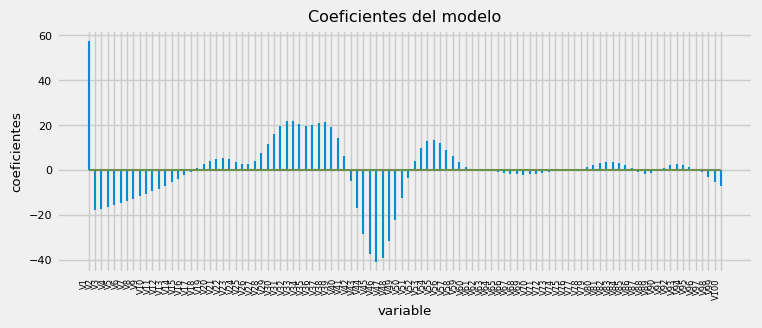

In [57]:
fig, ax = plt.subplots(figsize=(8, 3))
ax.stem(df_coef.predictor, df_coef.coef, markerfmt=' ')
plt.xticks(rotation=90, ha='right', size=6)
ax.set_xlabel('variable')
ax.set_ylabel('coeficientes')
ax.set_title('Coeficientes del modelo');


In [58]:
print_title('Predicciones test')

predictions = model.predict(X=X_test)
predictions = predictions.flatten()
predictions[:10]

 🔷 Predicciones test



array([21.928052  , 57.15034697, 44.91268747, 11.1630529 , 15.87694513,
        5.41735444, 25.664889  ,  9.81314946, 13.52380987, 22.91348811])

In [59]:
print_title('Error de test del modelo')

rmse_elastic = root_mean_squared_error(y_true=y_test, y_pred=predictions)
print(f'El error (RMSE) de test: {rmse_elastic}')

 🔷 Error de test del modelo

El error (RMSE) de test: 5.232998798175906


> Las predicciones del modelo final se alejan en promedio 5.23 unidades del valor real, usando solo 22 de los 100 predictores disponibles. Auqne el error es mayor que con Ridge o Lasso, el modelo es más simple (tiene menos predictores).

# Comparación

 🔷 Comparamos el error de test (rmse) de los 4 modelos



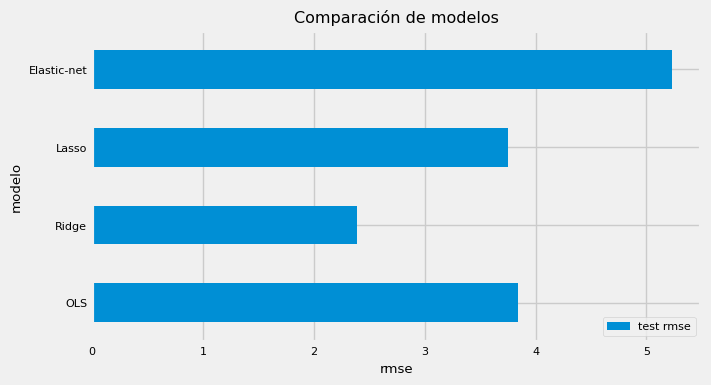

In [60]:
print_title('Comparamos el error de test (rmse) de los 4 modelos')


df_comparacion = pd.DataFrame({
                    'modelo': ['OLS', 'Ridge', 'Lasso', 'Elastic-net'],
                    'test rmse': [rmse_ols, rmse_ridge, rmse_lasso, rmse_elastic]
                 })

fig, ax = plt.subplots(figsize=(7, 3.84))
df_comparacion.set_index('modelo').plot(kind='barh', ax=ax)
ax.set_xlabel('rmse')
ax.set_ylabel('modelo')
ax.set_title('Comparación de modelos');


> En este caso, el mejor modelo en términos de error predictivo se obtiene aplicando Ridge. El modelo con Lasso tiene un error ligeramente superior al modelo OLS pero usa solo 24 predictores en lugar de 100, ofreciendo buen balance entre precisión e interpretabilidad. Por su parte Elastic-net ofrece el modelo más simple usando 22 predictores pero con mayor error.

# Referencias


### Fuentes:
- [Regularización Ridge Lasso y Elastic Net con Python](https://cienciadedatos.net/documentos/py14-ridge-lasso-elastic-net-python)
    - Linear Models with R by Julian J.Faraway

    - An Introduction to Statistical Learning: with Applications in R (Springer Texts in Statistics)

    - Applied Predictive Modeling by Max Kuhn and Kjell Johnson

    - The Elements of Statistical Learning by T.Hastie, R.Tibshirani, J.Friedman

    - Introduction to Machine Learning with Python: A Guide for Data Scientists

    - Python Data Science Handbook by Jake VanderPlas

    - Lever, J., Krzywinski, M. & Altman, N. Regularization. Nat Methods 13, 803–804 (2016)

### Uso de IA

- [Refuerzo para concepto de Regularización](https://chatgpt.com/share/6a0e85d7-90e4-83e9-9b42-070536ff26ee)